In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
train_df = pd.read_csv(
    "../data/processed/train_engineered.csv"
)

print(train_df.shape)

(61249, 54)


In [3]:
sensor_features = [
    col
    for col in train_df.columns
    if "_norm" in col
]

len(sensor_features)

18

In [4]:
X = train_df[sensor_features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled.shape

(61249, 18)

In [5]:
X_tensor = torch.tensor(
    X_scaled,
    dtype=torch.float32
)

dataset = TensorDataset(
    X_tensor
)

loader = DataLoader(
    dataset,
    batch_size=256,
    shuffle=True
)

In [6]:
class AutoEncoder(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),

            nn.Linear(16, 8),
            nn.ReLU(),

            nn.Linear(8, 4)
        )

        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),

            nn.Linear(8, 16),
            nn.ReLU(),

            nn.Linear(16, input_dim)
        )

    def forward(self, x):

        latent = self.encoder(x)

        reconstructed = self.decoder(
            latent
        )

        return reconstructed

In [7]:
input_dim = X_scaled.shape[1]

model = AutoEncoder(
    input_dim
)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [8]:
epochs = 20

loss_history = []

for epoch in range(epochs):

    total_loss = 0

    for batch in loader:

        x = batch[0]

        optimizer.zero_grad()

        output = model(x)

        loss = criterion(
            output,
            x
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = (
        total_loss
        /
        len(loader)
    )

    loss_history.append(
        avg_loss
    )

    print(
        f"Epoch {epoch+1}/{epochs} | Loss={avg_loss:.6f}"
    )

Epoch 1/20 | Loss=0.575141
Epoch 2/20 | Loss=0.299655
Epoch 3/20 | Loss=0.249310
Epoch 4/20 | Loss=0.203364
Epoch 5/20 | Loss=0.185950
Epoch 6/20 | Loss=0.169207
Epoch 7/20 | Loss=0.161582
Epoch 8/20 | Loss=0.153045
Epoch 9/20 | Loss=0.150174
Epoch 10/20 | Loss=0.148002
Epoch 11/20 | Loss=0.146124
Epoch 12/20 | Loss=0.144004
Epoch 13/20 | Loss=0.141765
Epoch 14/20 | Loss=0.139737
Epoch 15/20 | Loss=0.137811
Epoch 16/20 | Loss=0.135898
Epoch 17/20 | Loss=0.134215
Epoch 18/20 | Loss=0.132877
Epoch 19/20 | Loss=0.131759
Epoch 20/20 | Loss=0.130806


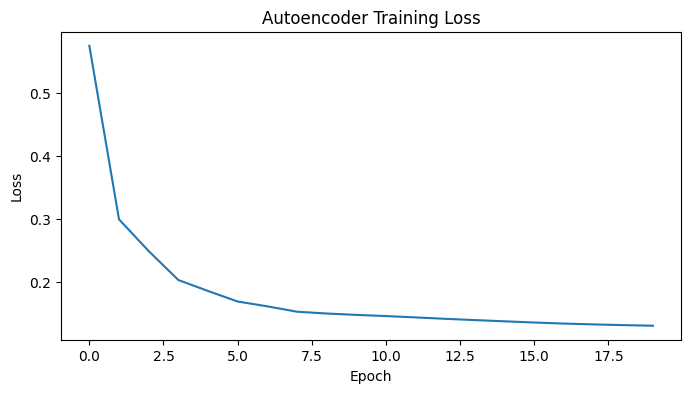

In [9]:
plt.figure(figsize=(8,4))

plt.plot(
    loss_history
)

plt.title(
    "Autoencoder Training Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [10]:
with torch.no_grad():

    reconstructed = model(
        X_tensor
    )

errors = torch.mean(
    (
        X_tensor
        -
        reconstructed
    ) ** 2,
    dim=1
).numpy()

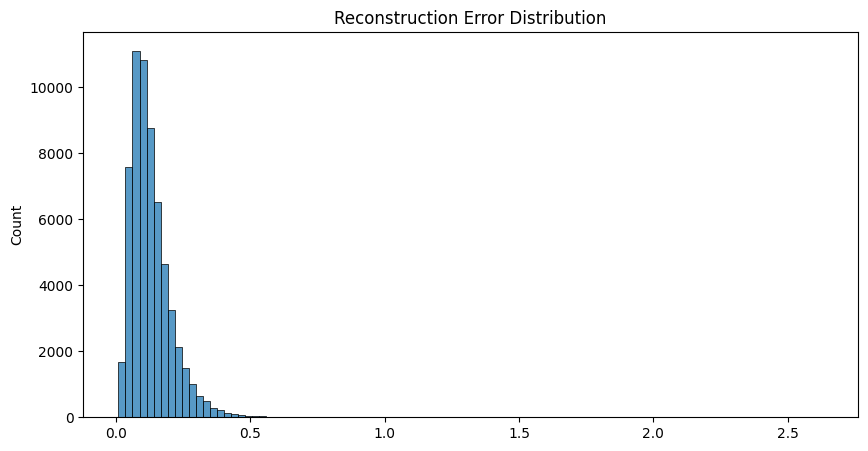

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(
    errors,
    bins=100
)

plt.title(
    "Reconstruction Error Distribution"
)

plt.show()

In [12]:
threshold = np.percentile(
    errors,
    97
)

threshold

np.float32(0.31165123)

In [13]:
train_df[
    "reconstruction_error"
] = errors

train_df[
    "autoencoder_anomaly"
] = (
    errors > threshold
).astype(int)

In [14]:
train_df[
    "autoencoder_anomaly"
].value_counts()

autoencoder_anomaly
0    59411
1     1838
Name: count, dtype: int64

In [15]:
train_df.groupby(
    "autoencoder_anomaly"
)["RUL"].describe()

,count,mean,std,min,25%,50%,75%,max
autoencoder_anomaly,,,,,,,,
0,59411.0,134.383818,89.455976,0.0,63.0,124.0,191.0,542.0
1,1838.0,98.647443,93.402016,0.0,18.0,72.0,158.0,487.0


In [16]:
comparison = pd.DataFrame({
    "Method": [
        "Isolation Forest",
        "Autoencoder"
    ],
    "Mean Anomaly RUL": [
        15.13,
        train_df[
            train_df[
                "autoencoder_anomaly"
            ] == 1
        ]["RUL"].mean()
    ]
})

comparison

,Method,Mean Anomaly RUL
0,Isolation Forest,15.130000
1,Autoencoder,98.647443


In [17]:
train_df.to_csv(
    "../data/processed/train_with_autoencoder_anomalies.csv",
    index=False
)

In [18]:
train_df["autoencoder_anomaly"].value_counts()

autoencoder_anomaly
0    59411
1     1838
Name: count, dtype: int64

In [19]:
train_df.groupby(
    "autoencoder_anomaly"
)["RUL"].describe()

,count,mean,std,min,25%,50%,75%,max
autoencoder_anomaly,,,,,,,,
0,59411.0,134.383818,89.455976,0.0,63.0,124.0,191.0,542.0
1,1838.0,98.647443,93.402016,0.0,18.0,72.0,158.0,487.0
